In [1]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import os; import sys
import numpy as np
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [2]:
# MPC import
from Deliverable_5_1.LinearMPC.MPCVelControl import MPCVelControl
from PIControl.PIControl import PIControl

from src.rocket import Rocket
from src.vel_rocket_vis import RocketVis, plot_static_states_inputs

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")

In [3]:
Ts = 0.05
sim_time = 10; H = 5.0
x0 = np.array([0, 0, 0, 0, 0, 0, 5, 5, 10, 0, 0, 1])  # initial state
x_target = np.zeros((12,))

rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
mpc = MPCVelControl().new_controller(rocket, Ts, H)

# Static mass change and zero fuel rate
rocket.mass = 1.5
rocket.fuel_rate = 0.0
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, ref = rocket.simulate_control(mpc, sim_time, H, x0, x_target=x_target, method='nonlinear')

vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, Ref=ref[:,:-1], T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol); 


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Simulating time 0.00: 
Simulating time 0.05: 
Simulating time 0.10: 
Simulating time 0.15: 
Simulating time 0.20: 
Simulating time 0.25: 
 State beta violation: -0.20 < -0.17, 
 State alpha violation: 0.20 > 0.17, 
Simulating time 0.30: 

/Users/amirlahlou/opt/anaconda3/envs/mpc2025/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(



 State beta violation: -0.21 < -0.17, 
 State alpha violation: 0.21 > 0.17, 
Simulating time 0.35: 
 State beta violation: -0.19 < -0.17, 
 State alpha violation: 0.20 > 0.17, 
Simulating time 0.40: 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.45: 
Simulating time 0.50: 
Simulating time 0.55: 
 State beta violation: -0.18 < -0.17, 
Simulating time 0.60: 
 State beta violation: -0.18 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 0.65: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 0.70: 
Simulating time 0.75: 
Simulating time 0.80: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.85: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.90: 
Simulating time 0.95: 
Simulating time 1.00: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 1.05: 
 State beta violation: -0.17 < -0.17, 

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=199, step=2), IntSlider(value=0…

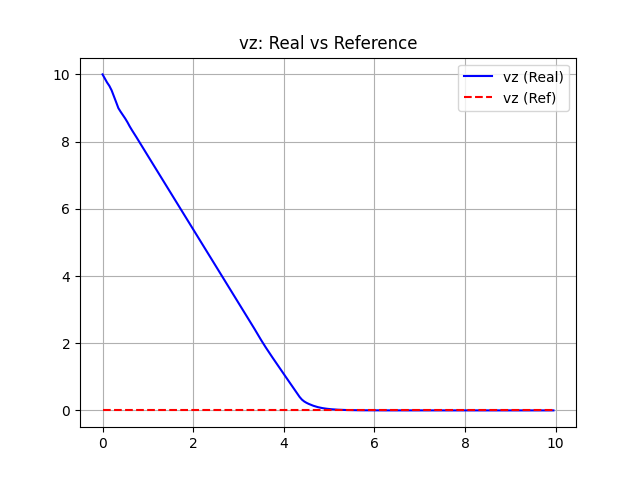

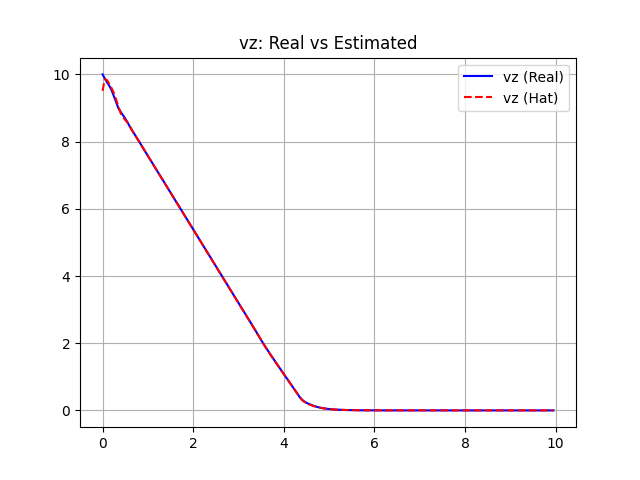

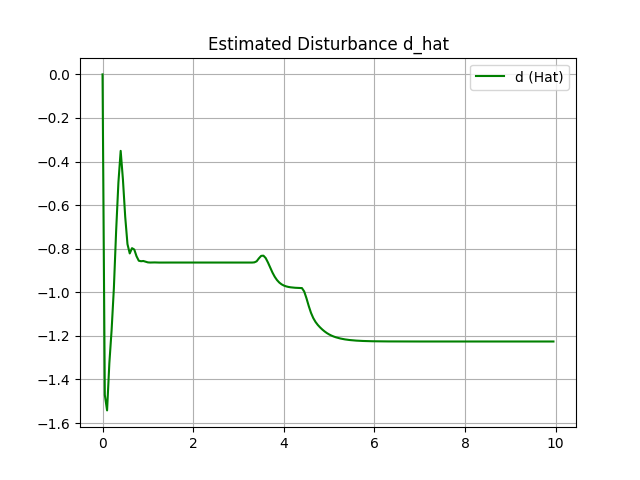

In [5]:
import matplotlib.pyplot as plt

# Retrieve histories from controller or simulation results
# Plot 1: Vz Real (x[8]) vs Ref (Ref[8])
# Note: x_cl is (12, N), ref is (12, N). t_cl is (N)
# Let's align lengths. t_cl[:-1] matches x_cl[:, :-1]
time_axis = t_cl[:-1]
vz_real = x_cl[8, :-1]
vz_ref = ref[8, :-1]

plt.figure()
plt.plot(time_axis, vz_real, 'b', label='vz (Real)')
plt.plot(time_axis, vz_ref, 'r--', label='vz (Ref)')
plt.legend()
plt.title('vz: Real vs Reference')
plt.grid(True)
plt.show()

# Plot 2: Vz Real vs Vz Hat
# vz_hat stored in mpc.mpc_z.x_hat_history. It is a list of arrays (1,).
# We need to flatten it.
vz_history = np.array(mpc.mpc_z.x_hat_history).flatten()

# Align lengths - history might have one more or less element depending on when it's updated
# sim_time / Ts = 10 / 0.05 = 200 steps.
# If history is longer, trim it. If shorter, trim time.
L = min(len(time_axis), len(vz_history))

plt.figure()
plt.plot(time_axis[:L], vz_real[:L], 'b', label='vz (Real)')
plt.plot(time_axis[:L], vz_history[:L], 'r--', label='vz (Hat)')
plt.legend()
plt.title('vz: Real vs Estimated')
plt.grid(True)
plt.show()

# Plot 3: Disturbance Estimate d_hat
d_history = np.array(mpc.mpc_z.d_hat_history).flatten()
L_d = min(len(time_axis), len(d_history))

plt.figure()
plt.plot(time_axis[:L_d], d_history[:L_d], 'g', label='d (Hat)')
plt.legend()
plt.title('Estimated Disturbance d_hat')
plt.grid(True)
plt.show()

In [ ]:
#ici

Simulating time 0.00: 
Simulating time 0.05: 
Simulating time 0.10: 
Simulating time 0.15: 
Simulating time 0.20: 
Simulating time 0.25: 
 State beta violation: -0.20 < -0.17, 
 State alpha violation: 0.20 > 0.17, 
Simulating time 0.30: 

/Users/amirlahlou/opt/anaconda3/envs/mpc2025/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(



 State beta violation: -0.21 < -0.17, 
 State alpha violation: 0.21 > 0.17, 
Simulating time 0.35: 
 State beta violation: -0.19 < -0.17, 
 State alpha violation: 0.20 > 0.17, 
Simulating time 0.40: 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.45: 
Simulating time 0.50: 
Simulating time 0.55: 
 State beta violation: -0.18 < -0.17, 
Simulating time 0.60: 
 State beta violation: -0.18 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 0.65: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 0.70: 
Simulating time 0.75: 
Simulating time 0.80: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.85: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.90: 
Simulating time 0.95: 
Simulating time 1.00: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 1.05: 
 State beta violation: -0.17 < -0.17, 

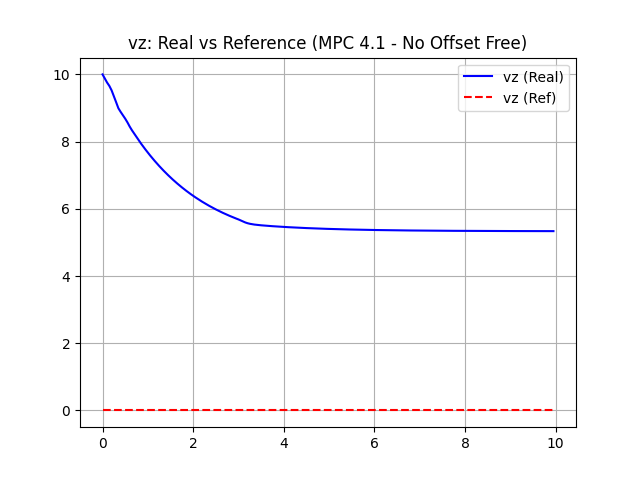

In [6]:
# ---------------------------------------------------------
# Comparison with Deliverable 4.1 Controller (Standard MPC)
# ---------------------------------------------------------

# Import MPCVelControl from Deliverable_4_1
from Deliverable_4_1.LinearMPC.MPCVelControl import MPCVelControl as MPCVelControl_4_1

# Setup Rocket and Controller
rocket_41 = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
mpc_41 = MPCVelControl_4_1().new_controller(rocket_41, Ts, H)

# Apply same disturbance: Static mass change and zero fuel rate
rocket_41.mass = 1.5
rocket_41.fuel_rate = 0.0

# Simulate
t_cl_41, x_cl_41, u_cl_41, t_ol, x_ol, u_ol, ref_41 = rocket_41.simulate_control(mpc_41, sim_time, H, x0, x_target=x_target, method='nonlinear')

# Plot 1: Vz Real vs Ref (MPC 4.1)
time_axis_41 = t_cl_41[:-1]
vz_real_41 = x_cl_41[8, :-1]
vz_ref_41 = ref_41[8, :-1]

plt.figure()
plt.plot(time_axis_41, vz_real_41, 'b', label='vz (Real)')
plt.plot(time_axis_41, vz_ref_41, 'r--', label='vz (Ref)')
plt.legend()
plt.title('vz: Real vs Reference (MPC 4.1 - No Offset Free)')
plt.grid(True)
plt.show()

# Note: MPC from Deliverable 4.1 does not have the observer (estimator), 
# so we cannot plot vz_hat or d_hat for this simulation.